Epoch 10 | Train Loss: 1.6977 | Test Loss: 1.5847 | Test Acc: 0.6778
Epoch 20 | Train Loss: 0.4484 | Test Loss: 0.3895 | Test Acc: 0.9111


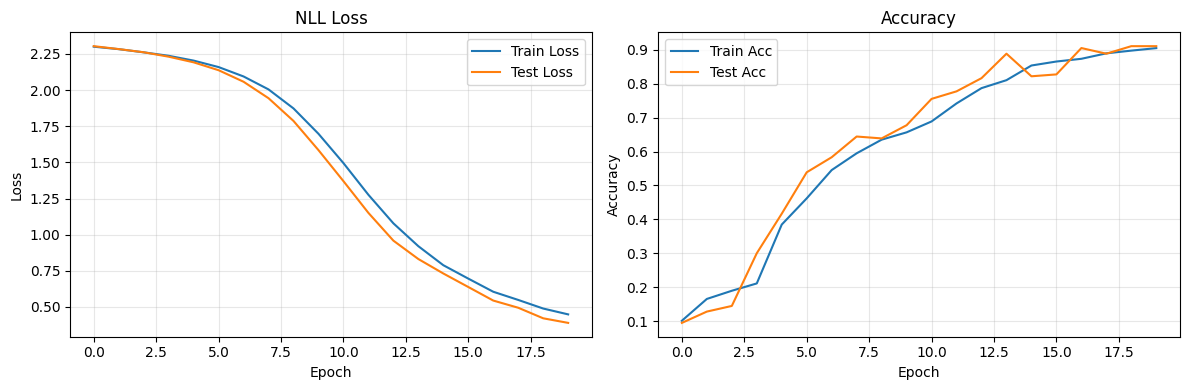


Финальная точность на тесте: 0.9111


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from students.uryvsky.lesson3 import Exercise

digits = load_digits()
X, y = digits.data.astype(np.float32) / 16.0, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

rng = np.random.default_rng(42)

model = Exercise.create_model(
    Exercise.create_linear_layer(64, 128, rng),
    Exercise.create_relu_layer(),
    Exercise.create_linear_layer(128, 64, rng),
    Exercise.create_relu_layer(),
    Exercise.create_linear_layer(64, 10, rng),
    Exercise.create_logsoftmax_layer(),
)

loss_fn = Exercise.create_nll_loss()

lr, n_epoch, batch_size = 0.01, 20, 16

train_losses, test_losses, train_accs, test_accs = [], [], [], []

for epoch in range(n_epoch):
    idx = np.random.permutation(len(X_train))
    X_shuffled, y_shuffled = X_train[idx], y_train[idx]

    epoch_loss = []
    correct = 0

    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]

        out = model.forward(X_batch)
        loss = loss_fn.forward(out, y_batch)
        epoch_loss.append(loss)

        pred = np.argmax(out, axis=1)
        correct += np.sum(pred == y_batch)

        model.backward(loss_fn.backward())
        for param, grad in zip(model.parameters, model.grad, strict=True):
            param -= grad * lr

    test_out = model.forward(X_test)
    test_loss = loss_fn.forward(test_out, y_test)
    test_pred = np.argmax(test_out, axis=1)
    test_acc = np.mean(test_pred == y_test)

    train_losses.append(np.mean(epoch_loss))
    test_losses.append(test_loss)
    train_accs.append(correct / len(X_train))
    test_accs.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1} | Train Loss: {train_losses[-1]:.4f} | "
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
        )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(test_losses, label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("NLL Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label="Train Acc")
ax2.plot(test_accs, label="Test Acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nФинальная точность на тесте: {test_accs[-1]:.4f}")